Krok 1.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('Heart_disease_cleveland_new.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [ ]:
print(df.shape) # ile wierszy i kolumn?
print(df.dtypes) # typy danych
print(df.describe()) # statystyki
print(df.isnull().sum()) # brakujące wartości

(303, 14)
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    2.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    2.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    2.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    3.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    3.000000  200.0



> ! Brak wartości pustych



* Age: Patients Age in years (Numeric)
* Sex: Gender (Male : 1; Female : 0) (Nominal)
* cp: Type of chest pain experienced by patient. This term categorized into 4 category.
0 typical angina, 1 atypical angina, 2 non- anginal pain, 3 asymptomatic (Nominal)
* trestbps: patient's level of blood pressure at resting mode in mm/HG (Numerical)
* chol: Serum cholesterol in mg/dl (Numeric)
* fbs: Blood sugar levels on fasting > 120 mg/dl represents as 1 in case of true and 0 as false (Nominal)
* restecg: Result of electrocardiogram while at rest are represented in 3 distinct values
0 : Normal 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
2: showing probable or definite left ventricular hypertrophyby Estes' criteria (Nominal)
* thalach: Maximum heart rate achieved (Numeric)
* exang: Angina induced by exercise 0 depicting NO 1 depicting Yes (Nominal)
* oldpeak: Exercise induced ST-depression in relative with the state of rest (Numeric)
* slope: ST segment measured in terms of slope during peak exercise
0: up sloping; 1: flat; 2: down sloping(Nominal)
* ca: The number of major vessels (0–3)(nominal)
* thal: A blood disorder called thalassemia
0: NULL 1: normal blood flow 2: fixed defect (no blood flow in some part of the heart) 3: reversible defect (a blood flow is observed but it is not normal(nominal)
* target: It is the target variable which we have to predict 1 means patient is suffering from heart disease and 0 means patient is normal.

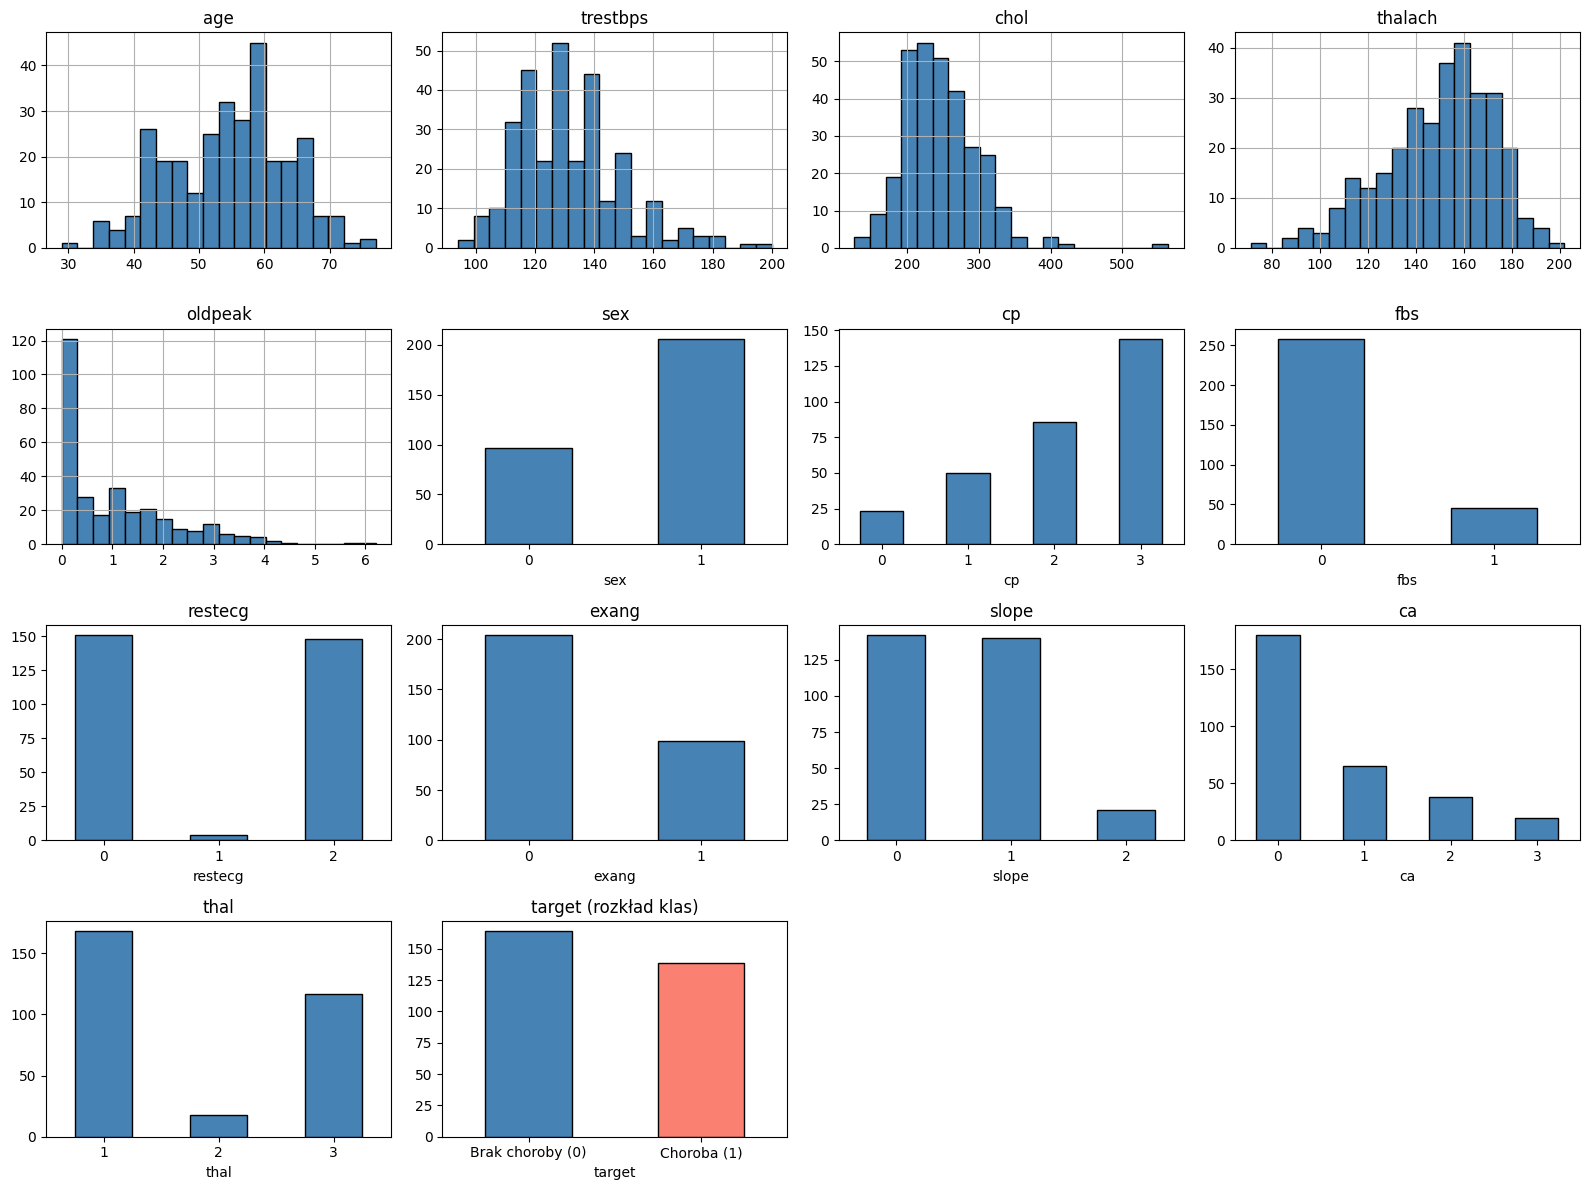

In [ ]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
continuous_cols = [col for col in df.drop('target', axis=1).columns
                   if col not in categorical_cols]

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

i = 0
# Ciągłe → histogram
for col in continuous_cols:
    df[col].hist(ax=axes[i], bins=20, edgecolor='black', color='steelblue')
    axes[i].set_title(col)
    i += 1

# Kategoryczne → bar chart
for col in categorical_cols:
    df[col].value_counts().sort_index().plot(
        kind='bar', ax=axes[i], edgecolor='black', color='steelblue'
    )
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=0)
    i += 1

# Target → bar chart z kolorami
df['target'].value_counts().sort_index().plot(
    kind='bar', ax=axes[i], color=['steelblue', 'salmon'], edgecolor='black'
)
axes[i].set_title('target (rozkład klas)')
axes[i].set_xticklabels(['Brak choroby (0)', 'Choroba (1)'], rotation=0)
i += 1

# Ukryj puste panele
for j in range(i, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Podział na dane do uczenia oraz testowe

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

> ! Zachowujemy podobne proporcje zdrowi-chorzy (54%/46%)

Krok 2.

In [ ]:
from sklearn.linear_model import LogisticRegression

# # Stworzenie i trening modelu
# model = LogisticRegression(random_state=42, max_iter=10000)
# model.fit(X_train, y_train)

# # Predykcja na zbiorze testowym
# y_pred = model.predict(X_test)

Od tego modelu zacząłem, jednak jak wykazały dalsze eksperymenty, domyślny solver lbfgs nie osiągał zbieżności na tym zbiorze danych nawet przy max_iter=10000, co oznacza że model zatrzymywał się przed osiągnięciem pełnego optimum. W kolejnych krokach zastosowano standaryzację danych (StandardScaler), która rozwiązała ten problem — model ze standaryzacją zbiega stabilnie i w znacznie mniejszej liczbie iteracji.

In [ ]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=1000, solver='saga')
model.fit(X_train_std, y_train)
y_pred = model.predict(X_test_std)

Krok 3.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Zdrowy (0)', 'Chory (1)']))

Accuracy: 0.8689

Classification Report:
              precision    recall  f1-score   support

  Zdrowy (0)       0.93      0.82      0.87        33
   Chory (1)       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



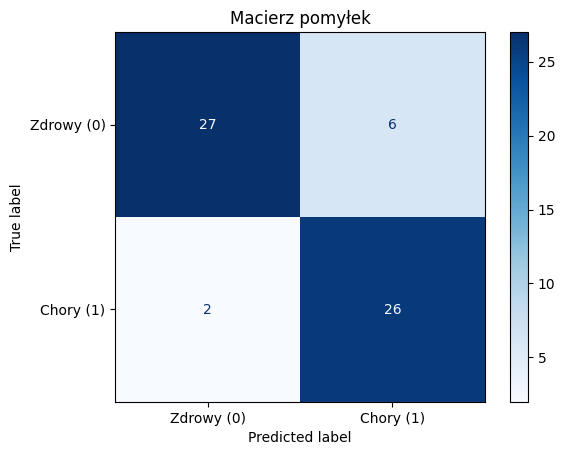

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Zdrowy (0)', 'Chory (1)'])
disp.plot(cmap='Blues')
plt.title('Macierz pomyłek')
plt.show()

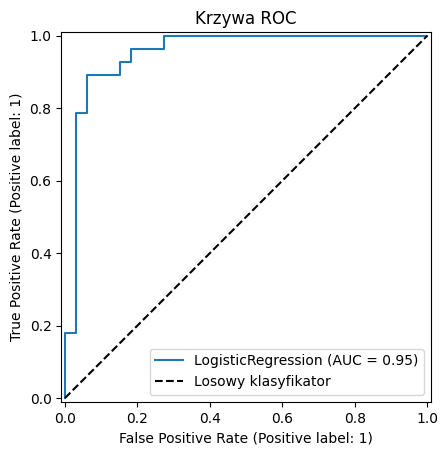

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test_std, y_test)
plt.title('Krzywa ROC')
plt.plot([0, 1], [0, 1], 'k--', label='Losowy klasyfikator')
plt.legend()
plt.show()

Krok 4.

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report

# Funkcja pomocnicza żeby nie powtarzać kodu
def evaluate_model(X_tr, X_te, y_tr, y_te, label):
    m = LogisticRegression(random_state=42, max_iter=1000, solver='saga')
    m.fit(X_tr, y_tr)
    y_p = m.predict(X_te)
    acc = accuracy_score(y_te, y_p)
    print(f"\n{'='*40}")
    print(f"Wariant: {label}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_te, y_p, target_names=['Zdrowy (0)', 'Chory (1)']))
    return acc

# Wariant 1: Bez skalowania (baseline - już masz)
acc_raw = evaluate_model(X_train, X_test, y_train, y_test, "Bez skalowania")

# Wariant 2: Standaryzacja (mean=0, std=1)
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)  # ważne: tylko transform, nie fit_transform!
acc_std = evaluate_model(X_train_std, X_test_std, y_train, y_test, "Standaryzacja (StandardScaler)")

# Wariant 3: Normalizacja (zakres 0-1)
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)
acc_mm = evaluate_model(X_train_mm, X_test_mm, y_train, y_test, "Normalizacja (MinMaxScaler)")


Wariant: Bez skalowania
Accuracy: 0.7869
              precision    recall  f1-score   support

  Zdrowy (0)       0.79      0.82      0.81        33
   Chory (1)       0.78      0.75      0.76        28

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61


Wariant: Standaryzacja (StandardScaler)
Accuracy: 0.8689
              precision    recall  f1-score   support

  Zdrowy (0)       0.93      0.82      0.87        33
   Chory (1)       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


Wariant: Normalizacja (MinMaxScaler)
Accuracy: 0.8525
              precision    recall  f1-score   support

  Zdrowy (0)       0.90      0.82      0.86        33
   Chory (1)       0.81      0.89      0.85        28

    accuracy               

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
for max_it in [1000, 2000, 5000, 10000]:
    m = LogisticRegression(random_state=42, max_iter=max_it)
    import warnings
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        m.fit(X_train_std, y_train)
        converged = len(w) == 0
    print(f"max_iter={max_it}: {'✅ zbiegł' if converged else '❌ nie zbiegł'}")

max_iter=1000: ❌ nie zbiegł
max_iter=2000: ❌ nie zbiegł
max_iter=5000: ❌ nie zbiegł
max_iter=10000: ❌ nie zbiegł


In [ ]:
# Porównanie: bez skalowania vs standaryzacja
for max_it in [1000, 2000, 5000, 10000]:
    for X_tr, label in [(X_train, "bez skalowania"), (X_train_std, "standaryzacja")]:
        m = LogisticRegression(random_state=42, max_iter=max_it)
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always")
            m.fit(X_tr, y_train)
            converged = len(w) == 0
        print(f"max_iter={max_it}, {label}: {'✅' if converged else '❌'}")

max_iter=1000, bez skalowania: ❌
max_iter=1000, standaryzacja: ❌
max_iter=2000, bez skalowania: ❌
max_iter=2000, standaryzacja: ❌
max_iter=5000, bez skalowania: ❌
max_iter=5000, standaryzacja: ❌
max_iter=10000, bez skalowania: ❌
max_iter=10000, standaryzacja: ❌


In [ ]:
for max_it in [100, 200, 500, 1000]:
    for X_tr, label in [(X_train, "bez skalowania"), (X_train_std, "standaryzacja")]:
        m = LogisticRegression(random_state=42, max_iter=max_it, solver='saga')
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always")
            m.fit(X_tr, y_train)
            converged = len(w) == 0
        print(f"max_iter={max_it}, {label}: {'✅' if converged else '❌'}")

max_iter=100, bez skalowania: ❌
max_iter=100, standaryzacja: ✅
max_iter=200, bez skalowania: ❌
max_iter=200, standaryzacja: ✅
max_iter=500, bez skalowania: ❌
max_iter=500, standaryzacja: ✅
max_iter=1000, bez skalowania: ❌
max_iter=1000, standaryzacja: ✅


Zbadano wpływ trzech wariantów preprocessingu na skuteczność klasyfikatora. Bez skalowania solver saga nie osiągał zbieżności, co przełożyło się na najniższe accuracy (78.7%). Normalizacja (MinMaxScaler) znacząco poprawiła wyniki (85.3%), jednak jest wrażliwa na wartości odstające obecne w zbiorze (np. chol=564). Najlepsze rezultaty osiągnięto przy standaryzacji (StandardScaler, 86.9%), która jest odporna na wartości odstające, ponieważ opiera się na średniej i odchyleniu standardowym zamiast na wartościach min/max. Na tej podstawie w dalszych eksperymentach stosowana jest standaryzacja jako domyślny preprocessing.

Krok 5.

Wpływ parametru C (penalty='l2'):
C          Accuracy     Recall (chory)  Precision (chory)
-------------------------------------------------------
0.001      0.8689       0.7500          0.9545
0.009      0.8852       0.8929          0.8621
0.01       0.8852       0.8929          0.8621
0.011      0.8852       0.8929          0.8621
0.02       0.8689       0.8929          0.8333
0.03       0.8525       0.8929          0.8065
0.09       0.8525       0.8929          0.8065
0.1        0.8689       0.9286          0.8125
0.11       0.8689       0.9286          0.8125
0.15       0.8689       0.9286          0.8125
1          0.8689       0.9286          0.8125
10         0.8689       0.9286          0.8125
100        0.8689       0.9286          0.8125
1000       0.8689       0.9286          0.8125


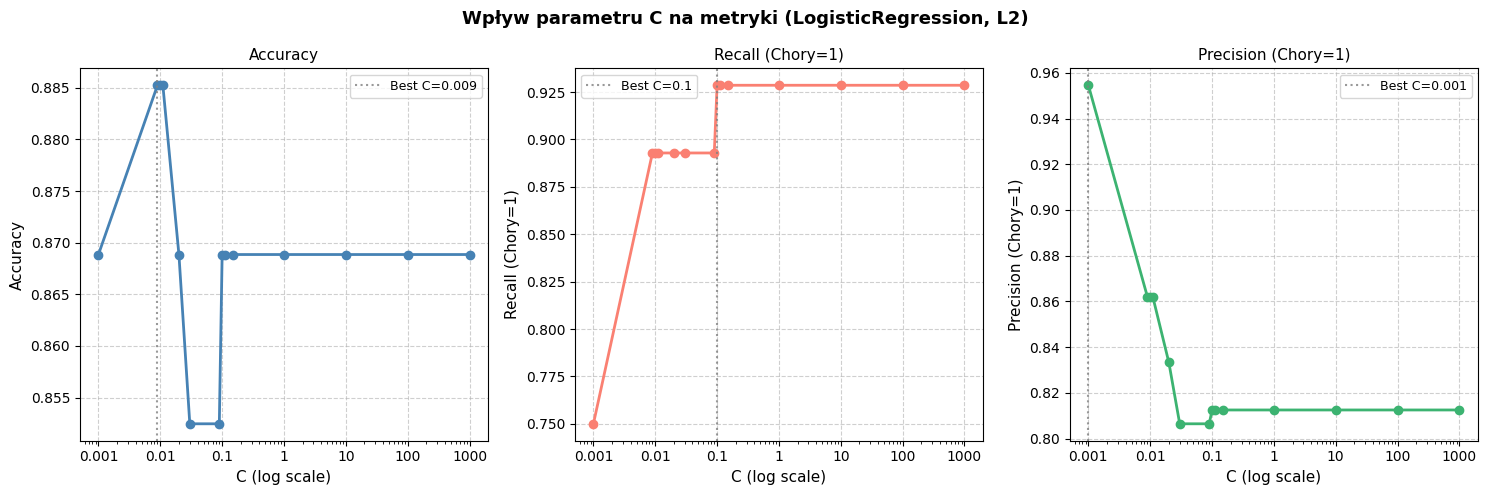

In [ ]:
# Badanie wpływu C (siła regularyzacji)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

C_values = [0.001, 0.009, 0.01, 0.011, 0.02, 0.03, 0.09, 0.1, 0.11, 0.15, 1, 10, 100, 1000]

print("Wpływ parametru C (penalty='l2'):")
print(f"{'C':<10} {'Accuracy':<12} {'Recall (chory)':<15} {'Precision (chory)'}")
print("-" * 55)

accuracies, recalls, precisions = [], [], []

for C in C_values:
    m = LogisticRegression(random_state=42, max_iter=1000, solver='saga', C=C)
    m.fit(X_train_std, y_train)
    y_p = m.predict(X_test_std)
    acc = accuracy_score(y_test, y_p)
    rep = classification_report(y_test, y_p, output_dict=True)
    recall = rep['1']['recall']
    prec = rep['1']['precision']
    print(f"{C:<10} {acc:<12.4f} {recall:<15.4f} {prec:.4f}")
    accuracies.append(acc)
    recalls.append(recall)
    precisions.append(prec)

# ── Wykres ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Wpływ parametru C na metryki (LogisticRegression, L2)", fontsize=13, fontweight='bold')

metrics = [
    (accuracies, "Accuracy",           "steelblue"),
    (recalls,    "Recall (Chory=1)",   "salmon"),
    (precisions, "Precision (Chory=1)","mediumseagreen"),
]

for ax, (values, label, color) in zip(axes, metrics):
    ax.semilogx(C_values, values, marker='o', color=color, linewidth=2, markersize=6)
    ax.set_xlabel("C (log scale)", fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(label, fontsize=11)
    ax.set_xticks([0.001, 0.01, 0.1, 1, 10, 100, 1000])
    ax.set_xticklabels(['0.001', '0.01', '0.1', '1', '10', '100', '1000'])
    ax.grid(True, linestyle='--', alpha=0.6)
    best_val = max(values)
    best_c = C_values[values.index(best_val)]
    ax.axvline(best_c, color='gray', linestyle=':', alpha=0.8, label=f'Best C={best_c}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
print("Wpływ parametru C (penalty='l1'):")
print(f"{'C':<10} {'Accuracy':<12} {'Recall (chory)':<15} {'Precision (chory)'}")
print("-" * 55)

for C in C_values:
    m = LogisticRegression(random_state=42, max_iter=1000, solver='saga',
                           penalty='l1', C=C)
    m.fit(X_train_std, y_train)
    y_p = m.predict(X_test_std)
    acc = accuracy_score(y_test, y_p)
    rep = classification_report(y_test, y_p, output_dict=True, zero_division=0)
    recall = rep['1']['recall']
    prec = rep['1']['precision']
    print(f"{C:<10} {acc:<12.4f} {recall:<15.4f} {prec:.4f}")

Wpływ parametru C (penalty='l1'):
C          Accuracy     Recall (chory)  Precision (chory)
-------------------------------------------------------
0.001      0.5410       0.0000          0.0000
0.009      0.5410       0.0000          0.0000
0.01       0.5410       0.0000          0.0000
0.011      0.5410       0.0000          0.0000
0.02       0.6721       0.5357          0.6818
0.03       0.7705       0.7500          0.7500
0.09       0.8525       0.8571          0.8276
0.1        0.8525       0.8571          0.8276
0.11       0.8525       0.8571          0.8276
0.15       0.8525       0.8571          0.8276
1          0.8689       0.9286          0.8125
10         0.8689       0.9286          0.8125
100        0.8689       0.9286          0.8125
1000       0.8689       0.9286          0.8125


Regularyzacja L1 wykazuje ostry próg działania.Poniżej C~0.02 model całkowicie degeneruje się zerując wszystkie współczynniki, podczas gdy L2 przy tym samym C nadal działało poprawnie (recall=0.75). Powyżej progu L1 stopniowo 'włącza' kolejne cechy i przy C≥1 osiąga identyczne wyniki jak L2, co sugeruje że przy słabej regularyzacji obie metody prowadzą do podobnego rozwiązania na tym zbiorze.

W zastosowaniu medycznym ważniejszy jest wysoki Recall (minimalizacja fałszywych negatywów), dlatego ostatecznie wybrano C=0.1 z regularyzacją L2, gdzie Recall=0.929 przy zachowaniu Accuracy=0.869.

In [ ]:
# Badanie wpływu l1_ratio (penalty='elasticnet')
l1_ratios = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]

print("\nWpływ parametru l1_ratio (elasticnet, C=1):")
print(f"{'l1_ratio':<12} {'Accuracy':<12} {'Recall (chory)':<15} {'Precision (chory)'}")
print("-" * 55)

for ratio in l1_ratios:
    m = LogisticRegression(random_state=42, max_iter=1000, solver='saga',
                           penalty='elasticnet', l1_ratio=ratio, C=1)
    m.fit(X_train_std, y_train)
    y_p = m.predict(X_test_std)
    acc = accuracy_score(y_test, y_p)
    rep = classification_report(y_test, y_p, output_dict=True)
    recall = rep['1']['recall']
    prec = rep['1']['precision']
    print(f"{ratio:<12} {acc:<12.4f} {recall:<15.4f} {prec:.4f}")


Wpływ parametru l1_ratio (elasticnet, C=1):
l1_ratio     Accuracy     Recall (chory)  Precision (chory)
-------------------------------------------------------
0.0          0.8689       0.9286          0.8125
0.1          0.8689       0.9286          0.8125
0.25         0.8689       0.9286          0.8125
0.5          0.8689       0.9286          0.8125
0.75         0.8689       0.9286          0.8125
0.9          0.8689       0.9286          0.8125
1.0          0.8689       0.9286          0.8125


Przy słabej regularyzacji (C=1) l1_ratio nie ma znaczenia, wszystkie wyniki identyczne.

In [ ]:
# Czy l1_ratio ma znaczenie przy silnej regularyzacji?
for ratio in [0.0, 0.25, 0.5, 0.75, 1.0]:
    m = LogisticRegression(random_state=42, max_iter=1000, solver='saga',
                           penalty='elasticnet', l1_ratio=ratio, C=0.001)
    m.fit(X_train_std, y_train)
    y_p = m.predict(X_test_std)
    acc = accuracy_score(y_test, y_p)
    rep = classification_report(y_test, y_p, output_dict=True, zero_division=0)
    print(f"l1_ratio={ratio}: acc={acc:.4f}, recall={rep['1']['recall']:.4f}")

l1_ratio=0.0: acc=0.8689, recall=0.7500
l1_ratio=0.25: acc=0.5410, recall=0.0000
l1_ratio=0.5: acc=0.5410, recall=0.0000
l1_ratio=0.75: acc=0.5410, recall=0.0000
l1_ratio=1.0: acc=0.5410, recall=0.0000


Przy silnej regularyzacji (C=0.001) już niewielki udział członu L1 (l1_ratio=0.25) powoduje degenerację modelu. Spycha on wszystkie współczynniki do zera i klasyfikuje każdą próbkę jako klasę większościową (zdrowy). Objawia się to accuracy równym udziałowi klasy dominującej w zbiorze testowym (~54%) i recallem równym 0 dla klasy mniejszościowej. Czyste L2 (l1_ratio=0.0) jest odporniejsze na ten efekt, gdyż minimalizuje wartości współczynników, ale nigdy nie zeruje ich całkowicie.

"czy l1_ratio ma znaczenie?" -> zależy od C - te dwa parametry są ze sobą powiązane i nie można ich badać w izolacji.

Krok 6.

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
import numpy as np

# Przygotowanie — skalujemy WSZYSTKIE dane (nie tylko train)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # tutaj używamy całego X, bo CV sam dzieli

model_cv = LogisticRegression(random_state=42, max_iter=1000, solver='saga')

# Test dla różnych k-fold BEZ stratyfikacji
print("Bez stratyfikacji:")
print(f"{'k-fold':<10} {'Mean Acc':<12} {'Std Acc':<12} {'Mean Recall':<14} {'Std Recall'}")
print("-" * 60)

for k in [2, 5, 10]:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    acc_scores = cross_val_score(model_cv, X_scaled, y, cv=kf, scoring='accuracy')
    recall_scores = cross_val_score(model_cv, X_scaled, y, cv=kf, scoring='recall')
    print(f"{k:<10} {acc_scores.mean():<12.4f} {acc_scores.std():<12.4f} {recall_scores.mean():<14.4f} {recall_scores.std():.4f}")

# Test dla różnych k-fold ZE stratyfikacją
print("\nZe stratyfikacją:")
print(f"{'k-fold':<10} {'Mean Acc':<12} {'Std Acc':<12} {'Mean Recall':<14} {'Std Recall'}")
print("-" * 60)

for k in [2, 5, 10]:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    acc_scores = cross_val_score(model_cv, X_scaled, y, cv=skf, scoring='accuracy')
    recall_scores = cross_val_score(model_cv, X_scaled, y, cv=skf, scoring='recall')
    print(f"{k:<10} {acc_scores.mean():<12.4f} {acc_scores.std():<12.4f} {recall_scores.mean():<14.4f} {recall_scores.std():.4f}")

Bez stratyfikacji:
k-fold     Mean Acc     Std Acc      Mean Recall    Std Recall
------------------------------------------------------------
2          0.8284       0.0072       0.7759         0.0296
5          0.8381       0.0291       0.7897         0.0778
10         0.8383       0.0541       0.8007         0.1194

Ze stratyfikacją:
k-fold     Mean Acc     Std Acc      Mean Recall    Std Recall
------------------------------------------------------------
2          0.8184       0.0105       0.7839         0.0447
5          0.8316       0.0496       0.7984         0.0667
10         0.8345       0.0638       0.7912         0.0814


Wraz ze wzrostem k rośnie średnie accuracy (model widzi więcej danych treningowych), ale też zmienność wyników - przy k=10 odchylenie standardowe accuracy jest ~7x większe niż przy k=2. Stratyfikacja nie przyniosła poprawy, co jest spójne z faktem że zbiór HDC jest stosunkowo zbalansowany (54%/46%) - losowy podział naturalnie zachowuje proporcje klas bez potrzeby wymuszania ich sztucznie.

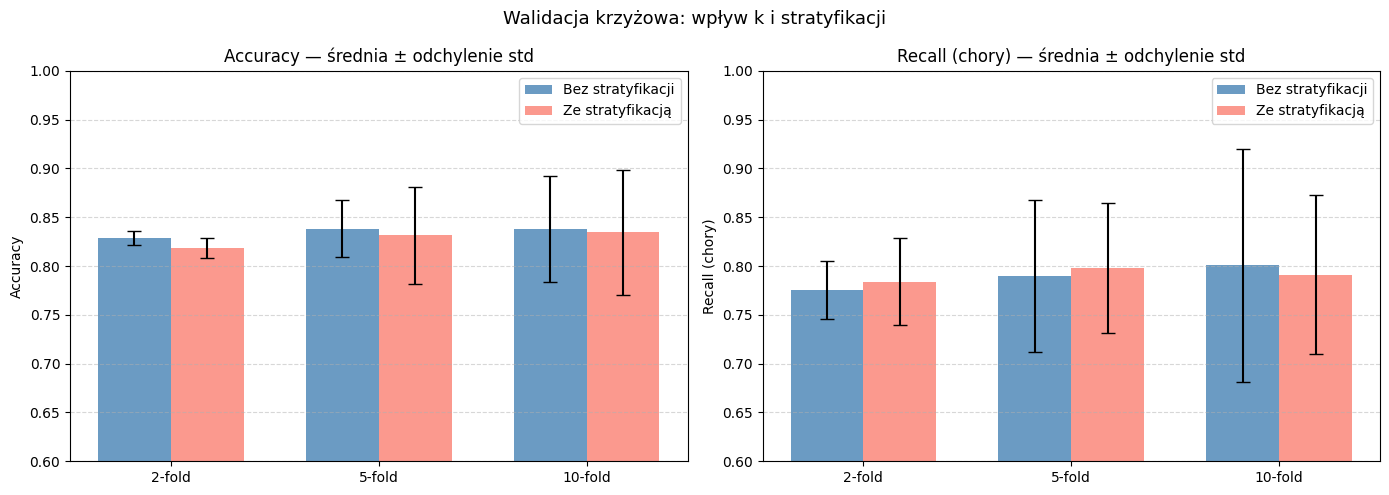

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

k_values = [2, 5, 10]

# Zbierz dane do wykresu
results = {'bez_strat': {'acc_mean': [], 'acc_std': [], 'recall_mean': [], 'recall_std': []},
           'ze_strat':  {'acc_mean': [], 'acc_std': [], 'recall_mean': [], 'recall_std': []}}

for k in k_values:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    for cv, key in [(kf, 'bez_strat'), (skf, 'ze_strat')]:
        acc = cross_val_score(model_cv, X_scaled, y, cv=cv, scoring='accuracy')
        rec = cross_val_score(model_cv, X_scaled, y, cv=cv, scoring='recall')
        results[key]['acc_mean'].append(acc.mean())
        results[key]['acc_std'].append(acc.std())
        results[key]['recall_mean'].append(rec.mean())
        results[key]['recall_std'].append(rec.std())

# Wykres
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['2-fold', '5-fold', '10-fold']
x = np.arange(len(k_values))
width = 0.35

for ax, metric, title in zip(axes, ['acc', 'recall'], ['Accuracy', 'Recall (chory)']):
    means_no = results['bez_strat'][f'{metric}_mean']
    stds_no  = results['bez_strat'][f'{metric}_std']
    means_st = results['ze_strat'][f'{metric}_mean']
    stds_st  = results['ze_strat'][f'{metric}_std']

    bars1 = ax.bar(x - width/2, means_no, width, yerr=stds_no, capsize=5,
                   label='Bez stratyfikacji', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, means_st, width, yerr=stds_st, capsize=5,
                   label='Ze stratyfikacją', color='salmon', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(f'{title} — średnia ± odchylenie std')
    ax.set_ylim(0.6, 1.0)
    ax.legend()
    ax.set_ylabel(title)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Walidacja krzyżowa: wpływ k i stratyfikacji', fontsize=13)
plt.tight_layout()
plt.show()

Wykres ilustruje klasyczny trade-off walidacji krzyżowej. Wraz ze wzrostem k średnie wyniki nieznacznie rosną, ale kosztem znacznie większej zmienności (dłuższe wąsy). Szczególnie widoczne jest to dla metryki recall przy k=10, gdzie odchylenie standardowe sięga ~0.12, co oznacza że wyniki między foldami różnią się nawet o 24 punkty procentowe. W praktyce k=5 jest najczęściej stosowanym kompromisem między stabilnością a jakością estymacji.